
# Exploratory Data Analysis - (EDA) Project

##  Client & Context

**Client:** Amy Williams  
**Role:** Property Seller  
**Profile:**
- Sells **luxury, central properties (top 10%)**
- Buys **average houses in outskirts** for strategic reasons

**Objective:**
Maximize profit from high-end property sales while acquiring low-profile properties at optimal prices.

---

##  Project Workflow

1. **Download the dataset (CSV)**
2. **Import the data**
3. **Data cleaning**
4. **Understand the data**
   - Generate hypotheses
   - Define key concepts
5. **Data visualization**
6. **Insights generation**
7. **Presentation of findings**

---

##  Understanding the Data

### Key Definitions

- **Luxury Houses**
  - Top 10% in price distribution
  - Premium features (e.g., waterfront, large area, modern condition)

- **Central vs Outskirts**
  - *Central:* High-value zip codes
  - *Outskirts:* Lower-value zip codes

- **Average Houses**
  - Mid-range pricing (e.g., 40th–60th percentile)
  - Standard features, no luxury premiums

- **Timing**
  - Identify seasonal price trends
  - Detect peak selling and low buying periods


## Data Visualization

- Distribution plots (price)
- Boxplots (price by zipcode)
- Scatterplot
- Time series plots (price over months)

---

## Strategy Definition

### SELL Strategy
Sell properties that:
- Are in the **top 10% price range**
- Located in **high-value zip codes**
- Have **premium features**
- Sold during **peak months**

---

###  BUY Strategy
Buy properties that:
- Are **mid-priced (average houses)**
- Located in **low-value zip codes (outskirts)**
- Have **good fundamentals**
- Purchased during **low-price periods**


In [48]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

##  Data Preparation

### Import Data
- Load CSV into pandas DataFrame


In [49]:

df = pd.read_csv("data/dataset.csv")
df.describe()


,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.159700e+04,2.159700e+04,21597.000000,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19206.000000,...,21597.000000,21597.000000,21145.000000,21597.000000,17749.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,5.402966e+05,4.580474e+09,10799.000000,4.580474e+09,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007602,...,7.657915,1788.596842,291.857224,1970.999676,836.650516,98077.951845,47.560093,-122.213983,1986.620318,12758.283512
std,3.673681e+05,2.876736e+09,6234.661218,2.876736e+09,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086858,...,1.173200,827.759761,442.490863,29.375234,4000.110554,53.513072,0.138552,0.140724,685.230472,27274.441950
min,7.800000e+04,1.000102e+06,1.000000,1.000102e+06,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,...,3.000000,370.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.220000e+05,2.123049e+09,5400.000000,2.123049e+09,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.904930e+09,10799.000000,3.904930e+09,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000
75%,6.450000e+05,7.308900e+09,16198.000000,7.308900e+09,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,9.900000e+09,21597.000000,9.900000e+09,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,...,13.000000,9410.000000,4820.000000,2015.000000,20150.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


#### First look at the dataset

Besides the invalid yr_renovated values, there are a few additional data quality issues worth addressing. Extremely high values in bedrooms (e.g., 33) likely represent errors and should be capped or removed. Some features such as waterfront and sqft_basement contain missing values that can reasonably be imputed as 0. Additionally, duplicate identifier columns (id, id.1) should be removed to avoid confusion. Overall, most variables are usable, but minor cleaning would improve reliability.


In [57]:
df[df["bedrooms"] > 10][
    ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "zipcode"]
].sort_values("bedrooms", ascending=False).iloc[1:]

df = df[~((df["bedrooms"] == 33) & (df["sqft_living"] == 1620))]


In [61]:
df[df["bathrooms"] > 7][
    ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "zipcode"]
].sort_values("bedrooms", ascending=False)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,zipcode
8537,450000.0,9.0,7.50,4050.0,6504.0,98144
12764,2280000.0,7.0,8.00,13540.0,307752.0,98053
7245,7700000.0,6.0,8.00,12050.0,27600.0,98102
9245,6890000.0,6.0,7.75,9890.0,31374.0,98039


In [55]:
df["yr_renovated"].value_counts().sort_index()

yr_renovated
0.0        17005
19340.0        1
19400.0        2
19440.0        1
19450.0        3
           ...  
20110.0        9
20120.0        8
20130.0       31
20140.0       73
20150.0       14
Name: count, Length: 70, dtype: int64

##  Data Cleaning
- Handle missing values  
- Remove duplicates  
- Fix data types  
- Validate consistency  




In [34]:
columns_needed = [
    'house_id',
    'date',
    'price',
    'zipcode',
    'lat',
    'long',
    'sqft_living',
    'sqft_lot',
    'bedrooms',
    'bathrooms',
    'floors',
    'grade',
    'condition',
    'waterfront',
    'view'
]

df_subset = df[columns_needed]
df_subset

,house_id,date,price,zipcode,lat,long,sqft_living,sqft_lot,bedrooms,bathrooms,floors,grade,condition,waterfront,view
0,7129300520,2014-10-13,221900.0,98178,47.5112,-122.257,1180.0,5650.0,3.0,1.00,1.0,7,3,NaN,0.0
1,6414100192,2014-12-09,538000.0,98125,47.7210,-122.319,2570.0,7242.0,3.0,2.25,2.0,7,3,0.0,0.0
2,5631500400,2015-02-25,180000.0,98028,47.7379,-122.233,770.0,10000.0,2.0,1.00,1.0,6,3,0.0,0.0
3,2487200875,2014-12-09,604000.0,98136,47.5208,-122.393,1960.0,5000.0,4.0,3.00,1.0,7,5,0.0,0.0
4,1954400510,2015-02-18,510000.0,98074,47.6168,-122.045,1680.0,8080.0,3.0,2.00,1.0,8,3,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21592,263000018,2014-05-21,360000.0,98103,47.6993,-122.346,1530.0,1131.0,3.0,2.50,3.0,8,3,0.0,0.0
21593,6600060120,2015-02-23,400000.0,98146,47.5107,-122.362,2310.0,5813.0,4.0,2.50,2.0,8,3,0.0,0.0
21594,1523300141,2014-06-23,402101.0,98144,47.5944,-122.299,1020.0,1350.0,2.0,0.75,2.0,7,3,0.0,0.0
21595,291310100,2015-01-16,400000.0,98027,47.5345,-122.069,1600.0,2388.0,3.0,2.50,2.0,8,3,NaN,0.0


In [35]:
df_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   house_id     21597 non-null  int64  
 1   date         21597 non-null  str    
 2   price        21597 non-null  float64
 3   zipcode      21597 non-null  int64  
 4   lat          21597 non-null  float64
 5   long         21597 non-null  float64
 6   sqft_living  21597 non-null  float64
 7   sqft_lot     21597 non-null  float64
 8   bedrooms     21597 non-null  float64
 9   bathrooms    21597 non-null  float64
 10  floors       21597 non-null  float64
 11  grade        21597 non-null  int64  
 12  condition    21597 non-null  int64  
 13  waterfront   19206 non-null  float64
 14  view         21534 non-null  float64
dtypes: float64(10), int64(4), str(1)
memory usage: 2.5 MB


In [36]:
# Date cleaning and added new columns around month and year
# filled missing values in view and waterfront with 0

df_subset["date"] = pd.to_datetime(df_subset["date"])
df_subset["year"] = df_subset["date"].dt.year
df_subset["month"] = df_subset["date"].dt.month
df_subset["view"] = df_subset["view"].fillna(0)
df_subset["waterfront"] = df_subset["waterfront"].fillna(0)



In [37]:
# Further cleaning convert values to int for readability

cols_to_int = [
    "bedrooms",
    "floors",
    "waterfront",
    "view",
    "grade",
    "condition",
    "sqft_lot",
    "sqft_living",
    "price"
]

for col in cols_to_int:
    if (df_subset[col] % 1 == 0).all():
        df_subset[col] = df_subset[col].astype("Int64")


In [38]:
# For house level analysis (not seasonality) we cleaned the dataset to keep only the last sales 
# record per house. The goal is to identify the luxury houses and what makes them luxurious

df_latest = (
    df_subset.sort_values("date")
      .drop_duplicates(subset="house_id", keep="last")
)

---

### Hypothesis 1
> Houses with premium features (e.g., waterfront, condition, grade) belong to the top 10% price segment.

### Hypothesis 2
> There are specific months where house prices peak (ideal for selling) and dip (ideal for buying).

### Hypothesis 3
> Houses in high-priced zipcodes are more likely to belong to the top 10% price segment.
---

## Luxury Segment (Top 10%)

###  Objective

The objective of this section is to identify what defines luxury properties (top 10% of prices), 
where they are located, and how this segment can be leveraged for strategic buying and selling decisions.

---

### Approach

To better understand this segment, we analyze the key characteristics of luxury properties, focusing on:

- **Size:** `sqft_living`, `sqft_lot`  
- **Structure:** `bedrooms`, `bathrooms`, `floors`  
- **Quality:** `grade`, `condition`  
- **Premium Features:** `waterfront`, `view`  

The goal is to identify what differentiates luxury homes from the rest of the market, both in terms of features and location.

---


In [62]:
price_threshold = df_latest["price"].quantile(0.9)
luxury_df = df_latest[df_latest["price"] >= price_threshold]

min_price = df_latest['price'].min()
max_price = df_latest['price'].max()
mean_price = df_latest['price'].mean()
price_threshold = np.percentile(df_latest['price'], 90)
luxury_df = df_subset[df_subset["price"] >= price_threshold]


print(f"Minimum house price: ${min_price:,.2f}")
print(f"Maximum house price: ${max_price:,.2f}")
print(f"Mean house price: ${mean_price:,.2f}")  

# Calculate the 90th percentile
print(f"Houses priced above ${price_threshold:,.2f} are considered luxury.")

Minimum house price: $78,000.00
Maximum house price: $7,700,000.00
Mean house price: $541,861.43
Houses priced above $889,000.00 are considered luxury.


In [40]:
# How many luxury houses are there?
num_luxury = luxury_df.shape[0]
print(f"There are {num_luxury} luxury houses.")
# Using .shape[0] gives you the number of rows, 
# which corresponds to the number of individual houses in that category.

There are 2153 luxury houses.


In [41]:
# Step 3: Determine "What Counts as Luxury"
# To understand what makes these houses "luxury," 
# you can look at the average (mean) values of their features. 
# This tells you the typical "recipe" for a luxury home in your dataset.

# Calculate mean features for luxury houses
luxury_features = luxury_df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'view']].mean()
print("Average features of a luxury house:")
print(luxury_features)


Average features of a luxury house:
bedrooms           4.019043
bathrooms          3.026939
sqft_living     3568.038551
sqft_lot       23479.593126
grade              9.516024
view               1.011147
dtype: Float64


In [42]:
# To see where these houses are concentrated, group them by their zipcode and count the occurrences. 
# This reveals the "luxury hubs."

# Distribution by Zipcode
location_dist = luxury_df['zipcode'].value_counts()

location_df = luxury_df["zipcode"].value_counts().reset_index()
location_df.columns = ["zipcode", "count"]

# Calculate share and cumulative share
location_df["share"] = location_df["count"] / location_df["count"].sum()
location_df["cum_share"] = location_df["share"].cumsum()

# Keep zipcodes that together make up ~90%
# Include the first zipcode that crosses the 90% boundary

top_90 = location_df[location_df["cum_share"] <= 0.9]
top_90 = location_df.iloc[:len(top_90) + 1].copy()


print(f"Number of zipcodes covering ~90% of luxury houses: {len(top_90)}")
print(top_90[["zipcode", "count", "share", "cum_share"]])

location_df["share"] = location_df["count"] / location_df["count"].sum()
location_df["cum_share"] = location_df["share"].cumsum()

# -----------------------------
# 3. Keep zipcodes that together make up ~90%
#    Include the first zipcode that crosses the 90% boundary
# -----------------------------
top_90 = location_df[location_df["cum_share"] <= 0.9]
top_90 = location_df.iloc[:len(top_90) + 1].copy()

# -----------------------------
# 4. Print summary
# -----------------------------
print(f"Number of zipcodes covering ~90% of luxury houses: {len(top_90)}")
print(top_90[["zipcode", "count", "share", "cum_share"]])


Number of zipcodes covering ~90% of luxury houses: 29
    zipcode  count     share  cum_share
0     98004    223  0.103576   0.103576
1     98040    183  0.084998   0.188574
2     98006    172  0.079889   0.268463
3     98112    140  0.065026   0.333488
4     98033    117  0.054343   0.387831
5     98199     87  0.040409   0.428240
6     98075     79  0.036693   0.464933
7     98105     75  0.034835   0.499768
8     98115     61  0.028333   0.528100
9     98053     60  0.027868   0.555968
10    98074     54  0.025081   0.581050
11    98119     53  0.024617   0.605667
12    98052     49  0.022759   0.628425
13    98005     48  0.022294   0.650720
14    98039     47  0.021830   0.672550
15    98177     44  0.020437   0.692987
16    98144     43  0.019972   0.712959
17    98117     39  0.018114   0.731073
18    98103     38  0.017650   0.748723
19    98027     38  0.017650   0.766373
20    98059     38  0.017650   0.784022
21    98116     38  0.017650   0.801672
22    98109     37  0.0171

/var/folders/h5/blx4m48s5t700m659401vvpw0000gn/T/ipykernel_18680/3992671402.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


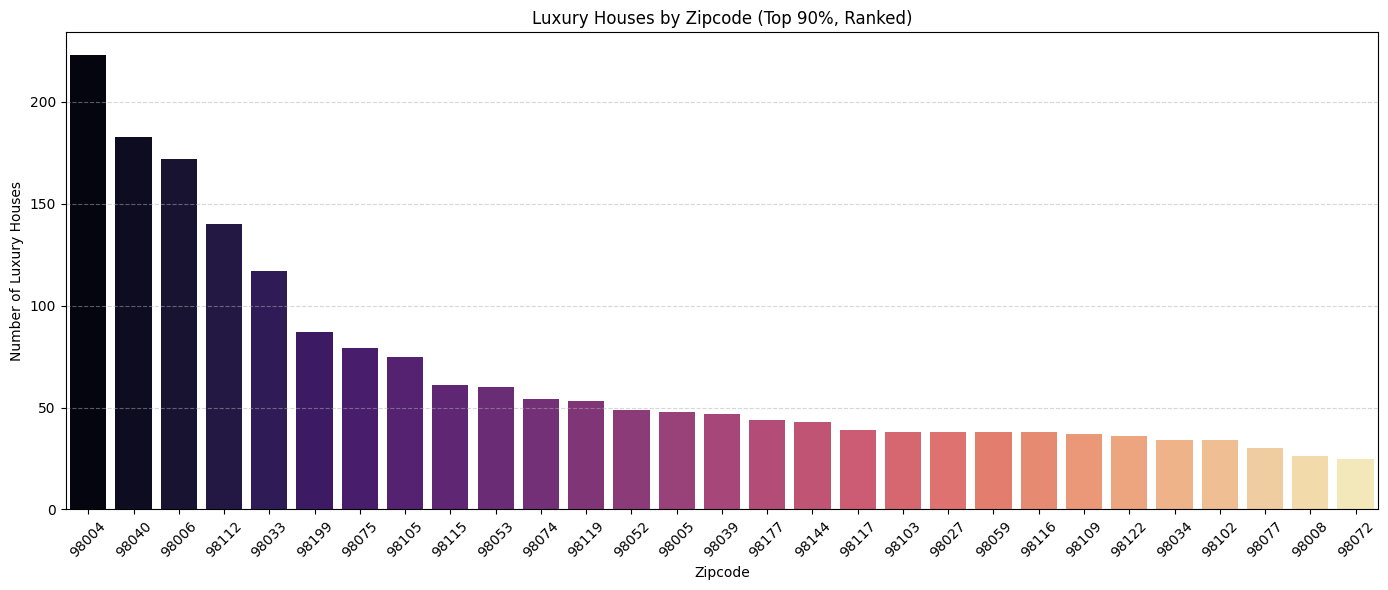

In [ ]:
top_90_sorted = top_90.sort_values(by="count", ascending=False)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_90_sorted,
    x="zipcode",
    y="count",
    palette="magma",
    order=top_90_sorted["zipcode"]  
)

plt.title("Luxury Houses by Zipcode (Top 90%, Ranked)")
plt.xlabel("Zipcode")
plt.ylabel("Number of Luxury Houses")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Insights

- Luxury properties are defined not only by size but by quality (grade) and location.
- The majority of luxury houses are concentrated in a limited number of zipcodes, indicating strong geographic clustering.
- This suggests that location plays a more significant role than individual house features alone in determining luxury pricing.

### Recommendations

- Focus selling efforts on properties located in established luxury zipcodes, where demand and willingness to pay are highest.
- Avoid assuming that large houses automatically qualify as luxury; location must be considered.
- Consider investing in properties near luxury clusters, as these areas may present opportunities for value appreciation.

###  Central vs Outskirts
- Use `zipcode` (primary), `lat/long` (optional)
- Central = **high average price areas**  
- Outskirts = **low average price areas**
- → SELL in central, BUY in outskirts

### Objective

### Insights


### Recommendations


## Selling Over Time (Seasonality Analysis)

- Use `date` → extract month/year
- Identify:
  - **Peak months → SELL**
  - **Low periods → BUY**

#### Objective

Understand how housing market activity varies over time to identify:

    When demand is highest → best time to SELL
    When activity is lowest → best time to BUY

#### Monthly Sales Volume

We first analyze how many houses are sold per month to identify seasonal patterns in market activity.

In [44]:
monthly_sales = df_subset.groupby("month").size()
top_3_sales = monthly_sales.sort_values(ascending=False).head(3)
bottom_3_sales = monthly_sales.sort_values(ascending=True).head(3)

print(" TOP 3 MONTHS (Overall Sales)")
print(top_3_sales.to_string())

print("\n BOTTOM 3 MONTHS (Overall Sales)")
print(bottom_3_sales.to_string())



 TOP 3 MONTHS (Overall Sales)
month
5    2414
4    2229
7    2211

 BOTTOM 3 MONTHS (Overall Sales)
month
1      978
2     1247
11    1409


In terms of overall sales:

📈 Peak months: May, April, July

📉 Low activity months: January, February, November

#### Luxury vs Overall Market

Next, we compare whether luxury houses follow the same seasonal pattern as the overall market.

In [45]:
luxury_monthly_sales = luxury_df.groupby("month").size()
top_3_luxury_sales = luxury_monthly_sales.sort_values(ascending=False).head(3)
bottom_3_luxury_sales = luxury_monthly_sales.sort_values(ascending=True).head(3)


print("\n TOP 3 MONTHS (Luxury Sales)")
print(top_3_luxury_sales.to_string())

print("\n BOTTOM 3 MONTHS (Luxury Sales)")
print(bottom_3_luxury_sales.to_string())


 TOP 3 MONTHS (Luxury Sales)
month
4    258
5    249
6    239

 BOTTOM 3 MONTHS (Luxury Sales)
month
1      87
2     104
11    132


Luxury houses peak in April–June

Low activity also in winter months

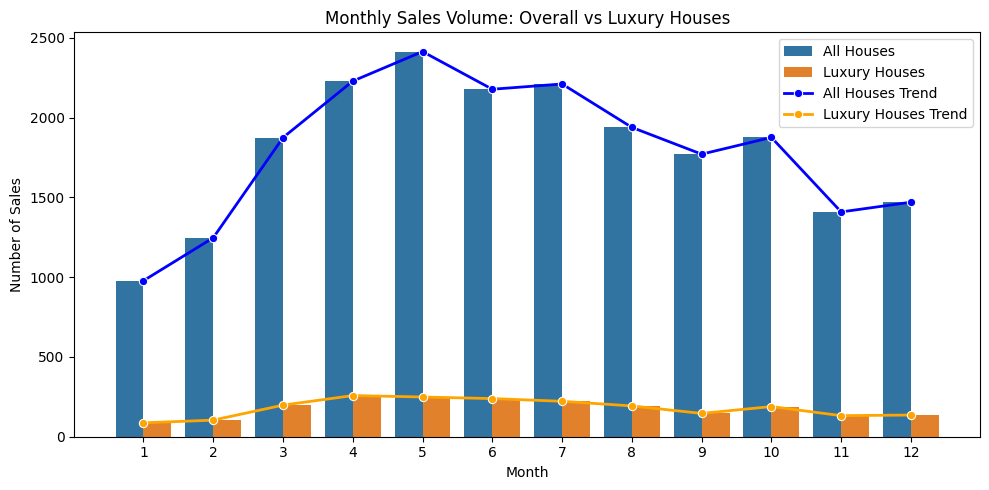

In [46]:

combined = pd.DataFrame({
    "month": monthly_sales.index.astype(str),
    "All Houses": monthly_sales.values,
    "Luxury Houses": luxury_monthly_sales.reindex(monthly_sales.index).values
})

combined_melted = combined.melt(
    id_vars="month",
    var_name="Type",
    value_name="Sales"
)

plt.figure(figsize=(10, 5))

# Grouped bars
sns.barplot(
    data=combined_melted,
    x="month",
    y="Sales",
    hue="Type"
)

# Overlay lines using the same x positions / same dataframe
sns.lineplot(
    data=combined,
    x="month",
    y="All Houses",
    marker="o",
    linewidth=2,
    color="blue",
    label="All Houses Trend"
)

sns.lineplot(
    data=combined,
    x="month",
    y="Luxury Houses",
    marker="o",
    linewidth=2,
    color="orange",
    label="Luxury Houses Trend"
)

plt.title("Monthly Sales Volume: Overall vs Luxury Houses")
plt.xlabel("Month")
plt.ylabel("Number of Sales")
plt.tight_layout()
plt.show()


#### Is the luxury share constant over time?

To validate whether seasonality is driven by changes in property types, we calculate the share of luxury houses over time for each month

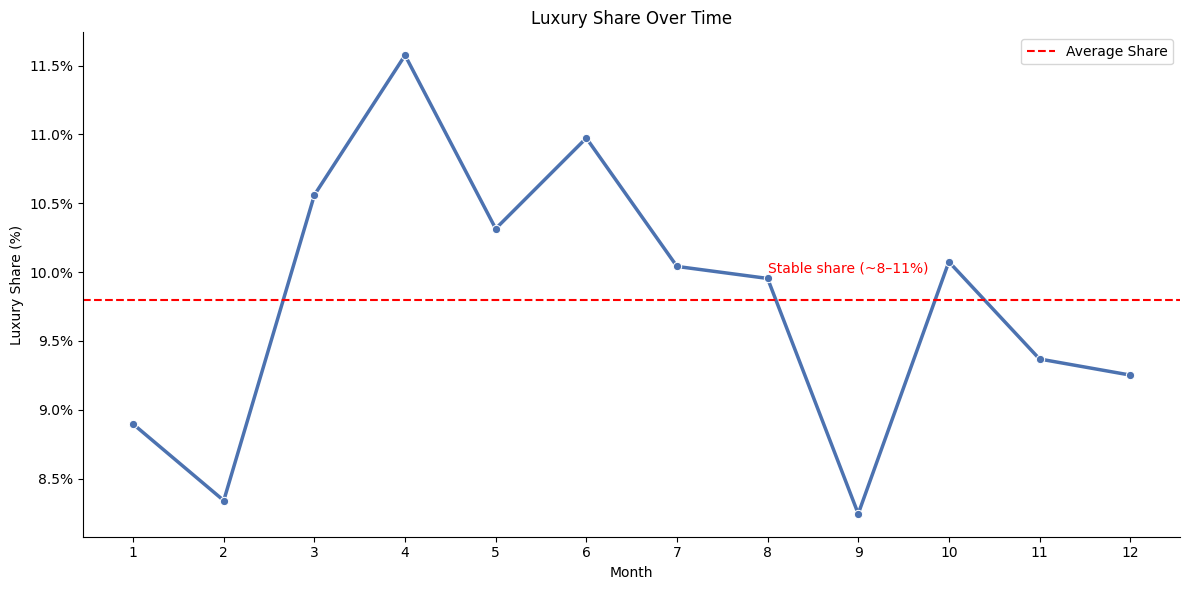

In [47]:

luxury_share = (
    luxury_monthly_sales / monthly_sales
)
luxury_share_df = luxury_share.reset_index()
luxury_share_df.columns = ["month", "share"]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=luxury_share_df,
    x="month",
    y="share",
    marker="o",
    linewidth=2.5,
    color="#4C72B0"
)

# Reference line
plt.axhline(
    y=luxury_share_df["share"].mean(),
    color="red",
    linestyle="--",
    label="Average Share"
)

plt.xticks(ticks=range(1, 13), labels=range(1, 13))
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x*100:.1f}%")

plt.title("Luxury Share Over Time")
plt.xlabel("Month")
plt.ylabel("Luxury Share (%)")

plt.text(8, luxury_share_df["share"].mean()+0.002,
         "Stable share (~8–11%)",
         color="red")

plt.legend()
sns.despine()

plt.tight_layout()
plt.show()

Luxury share remains relatively stable (~8%–11%)

No strong seasonal spikes in luxury proportion

#### Recommendations

Amy should sell her luxury properties in central locations during peak market months (April–June), when both overall and luxury demand are highest, maximizing liquidity and price potential.

Amy should acquire average properties in outskirt areas during winter months (January–February), when market activity is lowest, allowing for more discreet transactions and potentially better negotiation conditions.

Overall, based on the data we have seasonality is driven by transaction volume rather than property type.